In [20]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM

import torch
import numpy as np
from PIL import Image
import torchvision
from torchvision import datasets, models, transforms
from train import *
from glob import glob
import cv2

In [2]:
from datapipe import WGM_dataset
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM, AblationCAM

In [11]:
TRAIN_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/train_redmarked.csv"
VAL_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/val_redmarked.csv"

In [3]:
TRAIN_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/train_redmarked_downsampled.csv"
VAL_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/val_redmarked_downsampled.csv"

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
       # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

batch_size = 16

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
train_wgm = WGM_dataset(TRAIN_CSV_PATH, data_transforms, "train", batch_size)
val_wgm = WGM_dataset(VAL_CSV_PATH, data_transforms, "val", batch_size)

In [6]:
train_loader = train_wgm.build_data_pipe()
val_loader = val_wgm.build_data_pipe()
dataloaders = {"train":train_loader, "val": val_loader}


train_datasize = train_wgm.dataset_size()
val_datasize = val_wgm.dataset_size()
dataset_sizes = {'train':train_datasize, 'val':val_datasize}

In [7]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x7f46a8450a60>,
 'val': <torch.utils.data.dataloader.DataLoader at 0x7f46a8450a90>}

In [8]:
dataset_sizes

{'train': 61123, 'val': 29989}

In [10]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/221kusfe-logs.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/chxs7358-logs.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/3uctrn1o10.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/1m1bkrw240.pth'
model_ft = load_saved_model(path)

In [11]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    #mean = np.array([0.8965, 0.8875, 0.9023])
    #std = np.array([0.0807, 0.0911, 0.0849])
    mean = np.array([-0.0601, -0.0667, -0.0616])
    std = np.array([0.9118, 0.9479, 0.9625])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated
    
def save_image(input_tensor, path, name):
    inp = input_tensor.squeeze(0)
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    print(inp.shape)
    #mean = np.array([0.8965, 0.8875, 0.9023])
    #std = np.array([0.0807, 0.0911, 0.0849])
    mean = np.array([-0.0601, -0.0667, -0.0616])
    std = np.array([0.9118, 0.9479, 0.9625])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    img = Image.fromarray((inp* 255).astype(np.uint8))
    img.save(os.path.join(path, name + ".png"))
    return img


def visualize_model(model):
    was_training = model.training
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    act_white_labeled_gray = []
    act_gray_labeled_white = []
    imgs = []
    c1=0
    c2=0
    for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
        #print("-------------------",i,"--------------------")
        inputs=inputs.squeeze()
        labels = labels.squeeze()
        inputs = inputs.to(device)
        labels = labels.to(device)
        actual_labels = labels.tolist()
        outputs = model(inputs)
        scores.extend(outputs.cpu().tolist())
        _, preds = torch.max(outputs, 1)
        pred_labels = preds.tolist()
        wsi=[x[0] for x in wsi]
        #wsi_names.extend(wsi)
        if c1>=5:
            break
        for j in range(len(labels)):
            if (actual_labels[j]==0) and (pred_labels[j]==0):
                img = save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_g_act_g", wsi[0]+"_"+str(i)+"_"+str(j))
                imgs.append(img)
                c1=c1+1
    return c1, imgs

def gradcam(model_ft, image_path):
    img = Image.open(image_path)
    img = np.array(img)/255
    tr = transforms.Compose([transforms.ToTensor(), transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])])
    target_layers = [model_ft.layer4[-1]]
    cam = GradCAM(model=model_ft, target_layers=target_layers, use_cuda=True)
    input_tensor = tr(img).to(device, dtype=torch.float)
    output1 = model_ft(input_tensor.unsqueeze(0))
    _, preds = torch.max(output1, 1)
    print(preds)
    grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0))
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)     
    plt.imshow(Image.fromarray(visualization, 'RGB'))
    return Image.fromarray(visualization, 'RGB'), preds

def ablationCam(model_ft, image_path):
    img = Image.open(image_path)
    img = np.array(img)/255
    tr = transforms.Compose([transforms.ToTensor(), transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])])
    target_layers = [model_ft.layer4[-1]]
    cam = AblationCAM(model=model_ft, target_layers=target_layers, use_cuda=True)
    input_tensor = tr(img).to(device, dtype=torch.float)
    output1 = model_ft(input_tensor.unsqueeze(0))
    _, preds = torch.max(output1, 1)
    print(preds)
    grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0))
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)     
    plt.imshow(Image.fromarray(visualization, 'RGB'))
    return Image.fromarray(visualization, 'RGB'), preds
    

In [12]:
image_path = glob(os.path.join("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w","*.png"))
#for im in image_path:

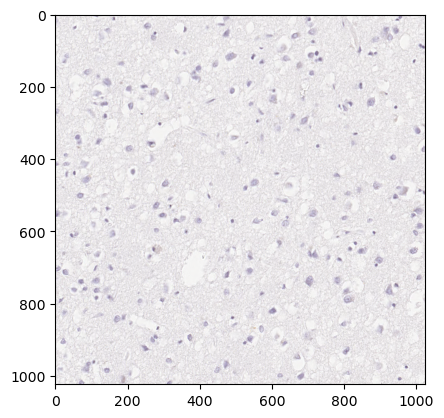

In [14]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray/5.png"
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_pred_act_gray/5.png"
plt.imshow(Image.open(im))

tensor([1], device='cuda:0')


(<PIL.Image.Image image mode=RGB size=1024x1024 at 0x7FB650201970>,
 tensor([1], device='cuda:0'))

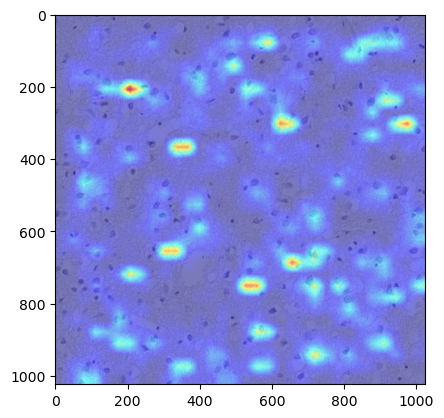

In [15]:
#im = image_path[4]
gradcam(model_ft, im)

In [4]:
img_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM"
image_path = glob(os.path.join(img_dir,"*.png"))


In [5]:
image_path

['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/PD090_Syn1_CG.svs_x_4279_y_15347.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/14_075_CG_aSyn_x200.svs_x_4892_y_1699.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/PD110_Syn1_CG.svs_x_5724_y_7831.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/12_007_CG_aSyn_x200.svs_x_13150_y_28280.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/12_007_CG_aSyn_x200.svs_x_11870_y_28024.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/PD133_Syn1_CG.svs_x_6087_y_12268.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/14_075_CG_aSyn_x200.svs_x_2332_y_9379.png']

In [6]:
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/PD090_Syn1_CG.svs_x_4279_y_15347.png'

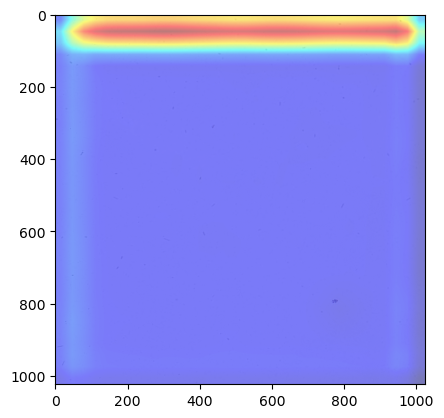

In [18]:
img = "/gladstone/finkbeiner/steve//work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/model-3uctrn1o10-output/2_13_177_CG_aSyn_x200.svs_x_19959_y_36313.png"
plt.imshow(Image.open(img))

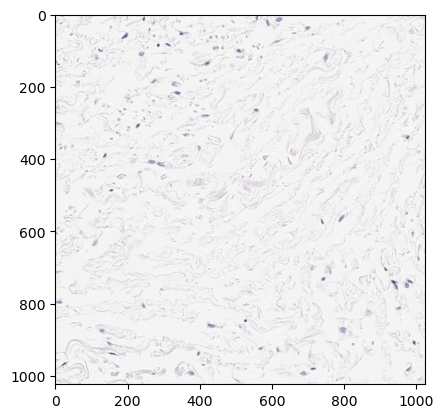

In [16]:
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/13_177_CG_aSyn_x200.svs_x_19191_y_32217.png'
plt.imshow(Image.open(img))

tensor([2], device='cuda:0')


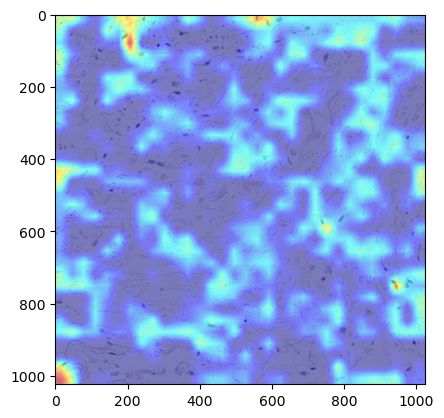

In [17]:
gc, pred =gradcam(model_ft, img)

tensor([0], device='cuda:0')


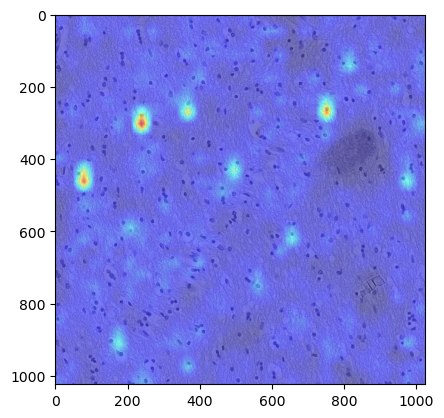

In [21]:
for im in image_path[:1]:
    plt.imshow(Image.open(im))
    gc, pred =gradcam(model_ft, im)
    #gc.save(os.path.join(img_dir,"model-chxs7358-output",str(pred.cpu().numpy()[0])+"_"+im.split("/")[-1]))
    #gc.save(os.path.join(img_dir,"model-3uctrn1o10-output",str(pred.cpu().numpy()[0])+"_"+im.split("/")[-1]))

In [22]:
im=image_path[0]

In [23]:
im

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/3.png'

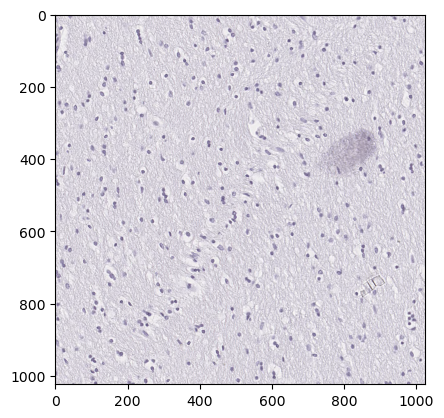

In [24]:
plt.imshow(Image.open(im))

tensor([0], device='cuda:0')


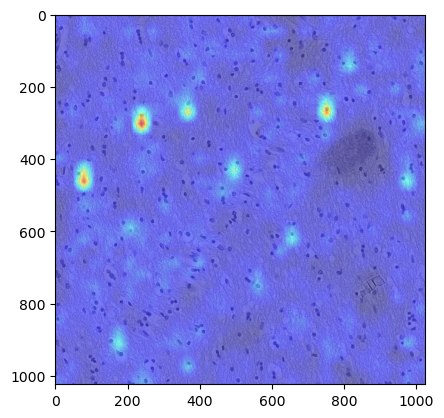

In [25]:
gc, pred =gradcam(model_ft, im)

In [33]:
im_a = np.array(Image.open(im))

In [34]:

im_a_rec = cv2.rectangle(im_a, (50, 900), (150, 850), (255, 255, 255), -1)
im_a_rec = cv2.rectangle(im_a_rec, (650, 900), (750, 800), (255, 255, 255), -1)
im_a_rec = cv2.rectangle(im_a_rec, (350, 300), (450,250), (255, 255, 255), -1)

In [8]:
im2 = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/model-3uctrn1o10-output/gradcam_on_modified_imgs/PD090_Syn1_CG.svs_x_4279_y_15347.png'
gc, pred =gradcam(model_ft, im2)

NameError: name 'gradcam' is not defined

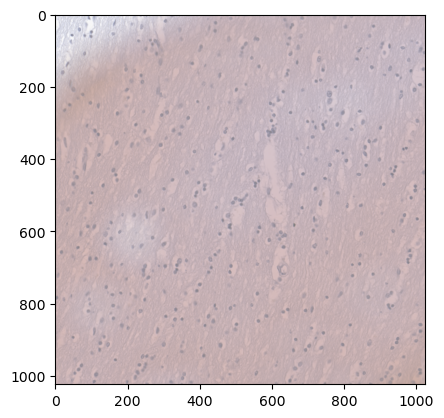

In [26]:
im = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Bad_WM/PD079_Syn1_CG.svs_x_2970_y_7365.png'
plt.imshow(Image.open(im))

tensor([0], device='cuda:0')


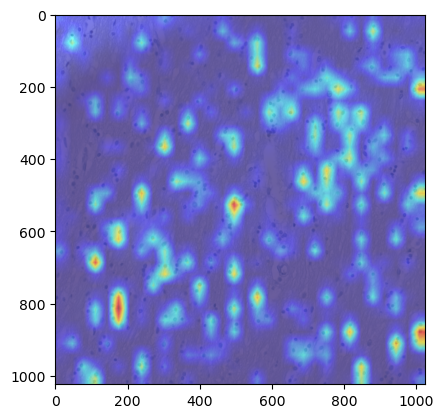

In [27]:
gc, pred =gradcam(model_ft, im)

In [42]:
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (700, 550), (900, 50), (255, 255, 255), -1)
im_a_rec = cv2.rectangle(im_a_rec, (180, 750), (220, 850), (255, 255, 255), -1)
im_a_rec = cv2.rectangle(im_a_rec, (400, 900), (600,850), (255, 255, 255), -1)

tensor([0], device='cuda:0')


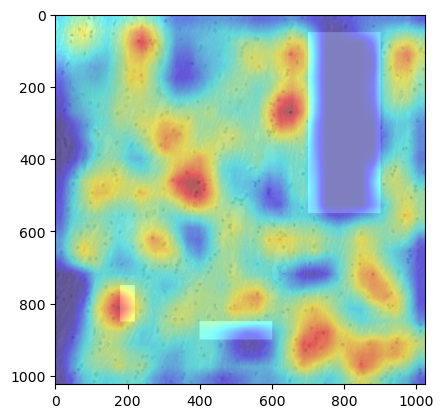

In [44]:
im2 = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Bad_WM/model-3uctrn1o10-output/gradcam_on_modified_imgs/PD079_Syn1_CG.svs_x_2970_y_7365.png'
gc, pred =gradcam(model_ft, im2)

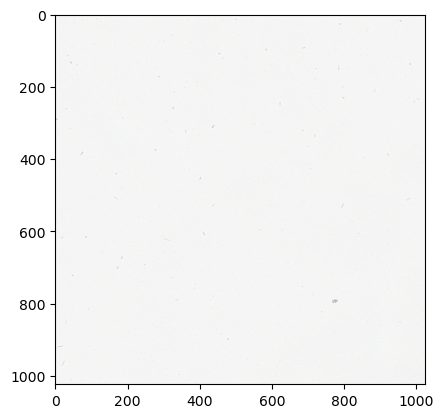

In [28]:
im = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/13_177_CG_aSyn_x200.svs_x_19959_y_36313.png'
plt.imshow(Image.open(im))

tensor([2], device='cuda:0')


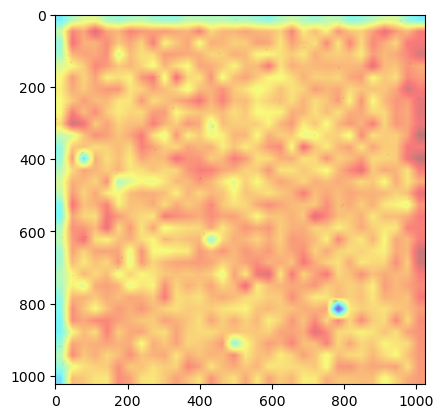

In [29]:
gc, pred =gradcam(model_ft, im)

In [50]:
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (0, 100), (1000, 0), (255, 255, 255), -1)
#im_a_rec = cv2.rectangle(im_a_rec, (180, 750), (220, 850), (255, 255, 255), -1)
#im_a_rec = cv2.rectangle(im_a_rec, (400, 900), (600,850), (255, 255, 255), -1)

tensor([2], device='cuda:0')


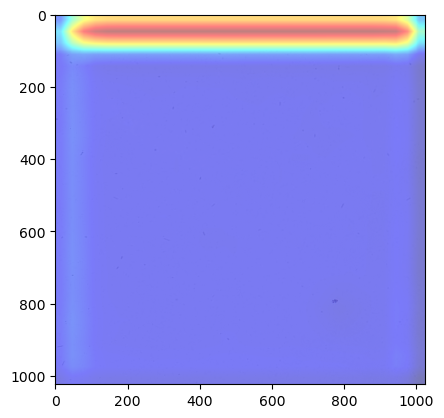

In [61]:
im2 = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/model-3uctrn1o10-output/gradcam_on_modified_imgs/13_177_CG_aSyn_x200.svs_x_19959_y_36313.png'
gc, pred =gradcam(model_ft, im2)

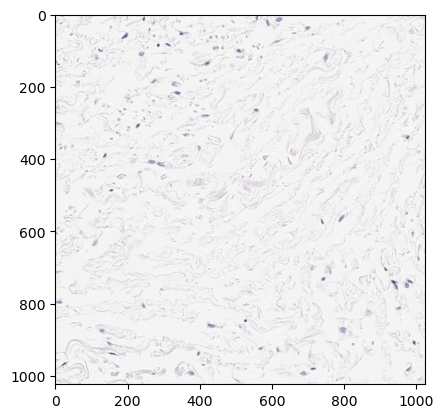

In [30]:
im = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/13_177_CG_aSyn_x200.svs_x_19191_y_32217.png'
plt.imshow(Image.open(im))

tensor([2], device='cuda:0')


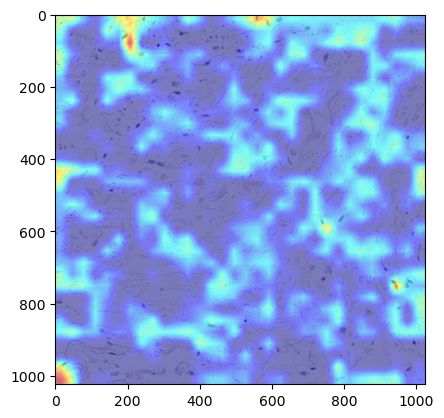

In [31]:
gc, pred =gradcam(model_ft, im)

In [57]:
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (0, 100), (1000, 0), (255, 255, 255), -1)

tensor([2], device='cuda:0')


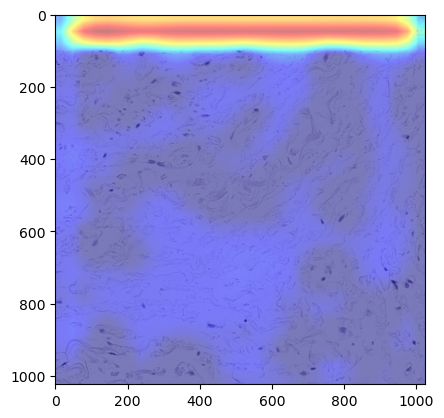

In [59]:
im2 = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/model-3uctrn1o10-output/gradcam_on_modified_imgs/13_177_CG_aSyn_x200.svs_x_19191_y_32217.png'
gc, pred =gradcam(model_ft, im2)

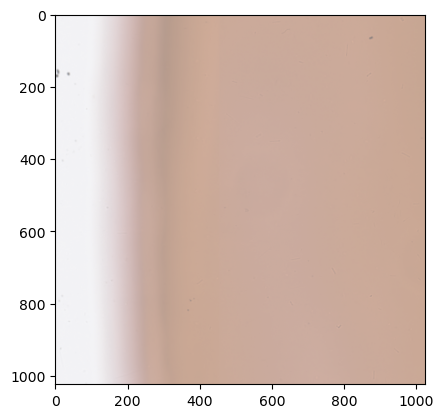

In [35]:
im = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/PD013_Syn1_CG.svs_x_1536_y_12185.png'
plt.imshow(Image.open(im))

tensor([1], device='cuda:0')


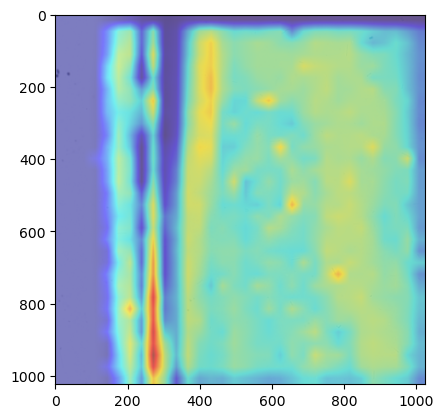

: 

In [36]:
gc, pred =gradcam(model_ft, im)

In [79]:
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (0, 1000), (300, 0), (0, 0, 0), -1)

In [96]:
im_a = np.array(Image.open(im))
crop_img = im_a[0:1000,400:1000]

In [94]:
crop_img.shape

(600, 1000, 3)

tensor([1], device='cuda:0')


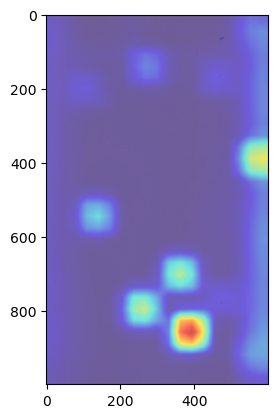

In [98]:
im2 = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/BG/model-3uctrn1o10-output/gradcam_on_modified_imgs/PD013_Syn1_CG.svs_x_1536_y_12185_3.png'
gc, pred =gradcam(model_ft, im2)

In [20]:
output_df = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/3uctrn1o10-misclassification/output_labels.csv")

In [21]:
output_df["wsi_name"].unique()

array(['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images_RedMarked/PD090_Syn1_CG.svs/White/PD090_Syn1_CG.svs_x_27829_y_6947.png',
       '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images_RedMarked/PD090_Syn1_CG.svs/White/PD090_Syn1_CG.svs_x_29365_y_4643.png',
       '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images_RedMarked/PD090_Syn1_CG.svs/White/PD090_Syn1_CG.svs_x_34493_y_16894.png',
       ...,
       '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/14_075_CG_aSyn_x200.svs/bg/14_075_CG_aSyn_x200.svs_x_7749_y_31801.png',
       '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/14_075_CG_aSyn_x200.svs/bg/14_075_CG_aSyn_x200.svs_x_13893_y_36409.png',
       '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/14_075_CG_aSyn_x200.svs/bg/14_075_CG_aSyn_x200.svs_x_6213_y_36665.png'],
      dtype=object)

In [22]:
output_df = output_df.drop(["Unnamed: 0"],axis=1)

In [23]:
output_df

,wsi_name,actual_labels,pred_labels,scores
0,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[3.364793539047241, -4.028471946716309, -5.196..."
1,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[2.337585687637329, -3.4083027839660645, -3.96..."
2,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[2.542856454849243, -3.175358295440674, -4.571..."
3,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[3.7732112407684326, -4.585071086883545, -4.79..."
4,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[4.743752956390381, -5.751691818237305, -5.206..."
...,...,...,...,...
29984,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,2,"[-6.04874324798584, -4.487552165985107, 6.7507..."
29985,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,2,"[-6.224143981933594, -4.393301486968994, 6.803..."
29986,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,2,"[-6.131080627441406, -4.409677982330322, 6.758..."
29987,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,2,"[-6.012399196624756, -4.385941982269287, 6.677..."


In [50]:
unmatched_crops = output_df[(output_df["actual_labels"]==0) & (output_df["pred_labels"]==1)]["wsi_name"].values

In [39]:
output_df[output_df["wsi_name"]==im]

,wsi_name,actual_labels,pred_labels,scores
9639,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[-0.26116612553596497, 1.7151868343353271, -7...."


In [66]:
im = np.random.choice(unmatched_crops)
im

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/13_177_CG_aSyn_x200.svs/White/13_177_CG_aSyn_x200.svs_x_12662_y_11611.png'

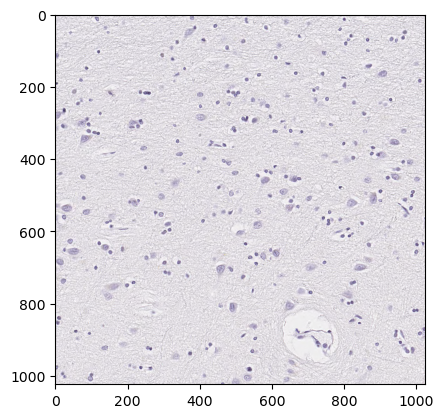

In [67]:
#im = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/13_177_CG_aSyn_x200.svs/White/13_177_CG_aSyn_x200.svs_x_12918_y_11611.png'
plt.imshow(Image.open(im))

tensor([0], device='cuda:0')


100%|██████████| 64/64 [00:47<00:00,  1.34it/s]


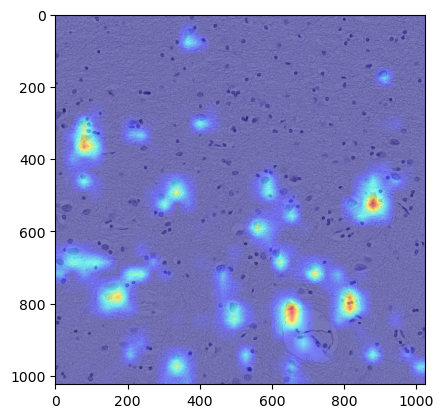

: 

In [68]:
gc, pred =ablationCam(model_ft, im)

In [ ]:
plt.imshow(gc)

In [119]:
import cv2
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (600, 950), (750, 850), (255, 255, 255), -1)

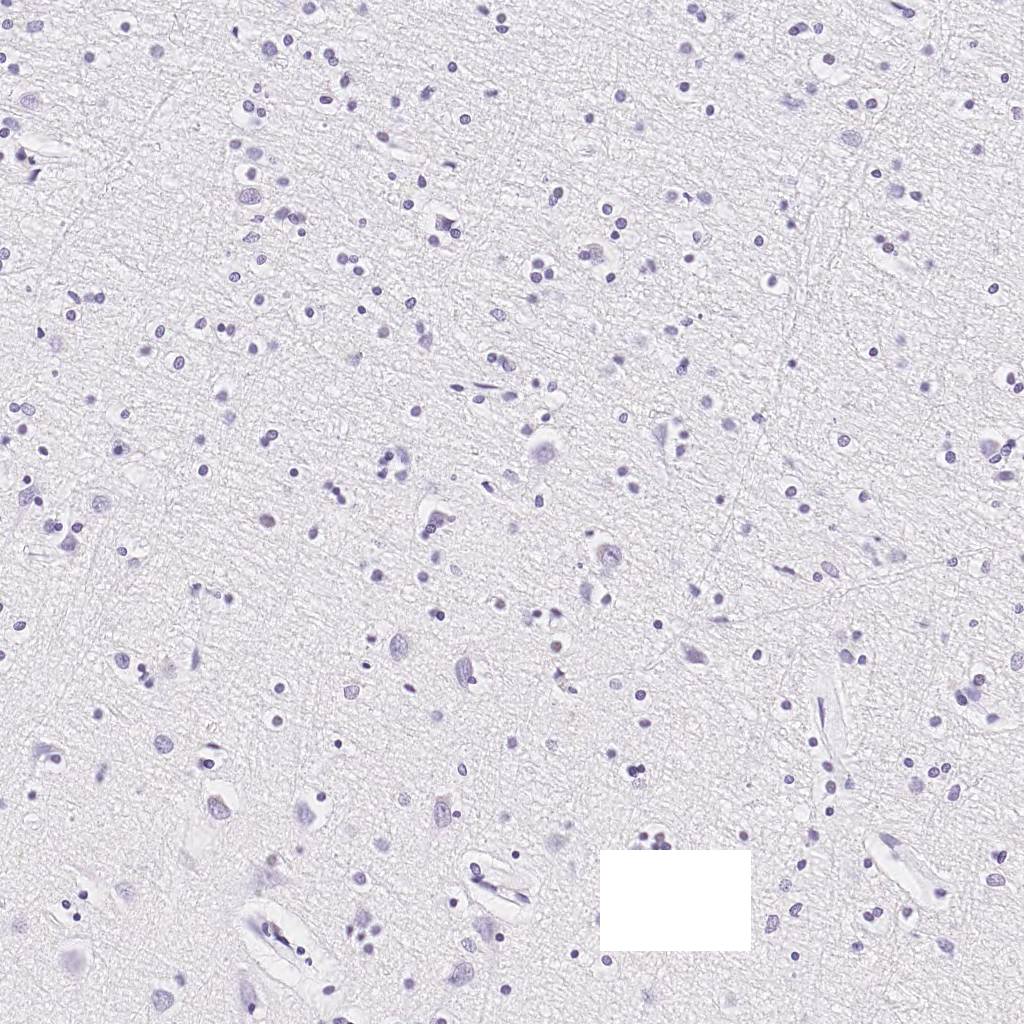

In [120]:
Image.fromarray(im_a_rec)

tensor([0], device='cuda:0')


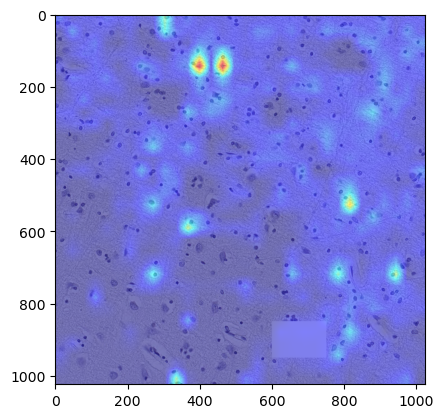

In [34]:
im2= '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/3uctrn1o10-misclassification/12.orig_white_pred_gray_patched.png'
gc, pred =gradcam(model_ft, im2)

tensor([1], device='cuda:0')


100%|██████████| 64/64 [00:52<00:00,  1.21it/s]


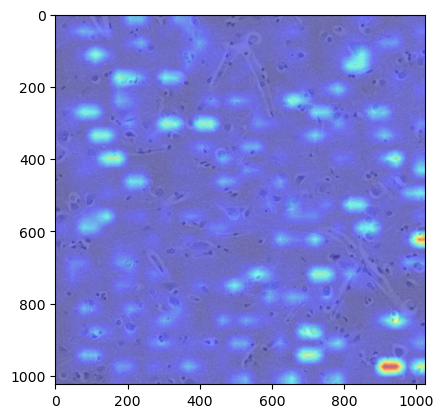

In [18]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/input_images/PD090_Syn1_CG.svs_x_4279_y_15347.png"
gc, pred =ablationCam(model_ft, im)

In [44]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/input_images/PD090_Syn1_CG.svs_x_4279_y_15347.png"
im_a = np.array(Image.open(im))
im_a_rec = cv2.rectangle(im_a, (900, 900), (1000, 1000), (255, 255, 255), -1)
im_a_rec = cv2.rectangle(im_a, (1024, 0), (0, 1024), (255, 255, 255), -1)

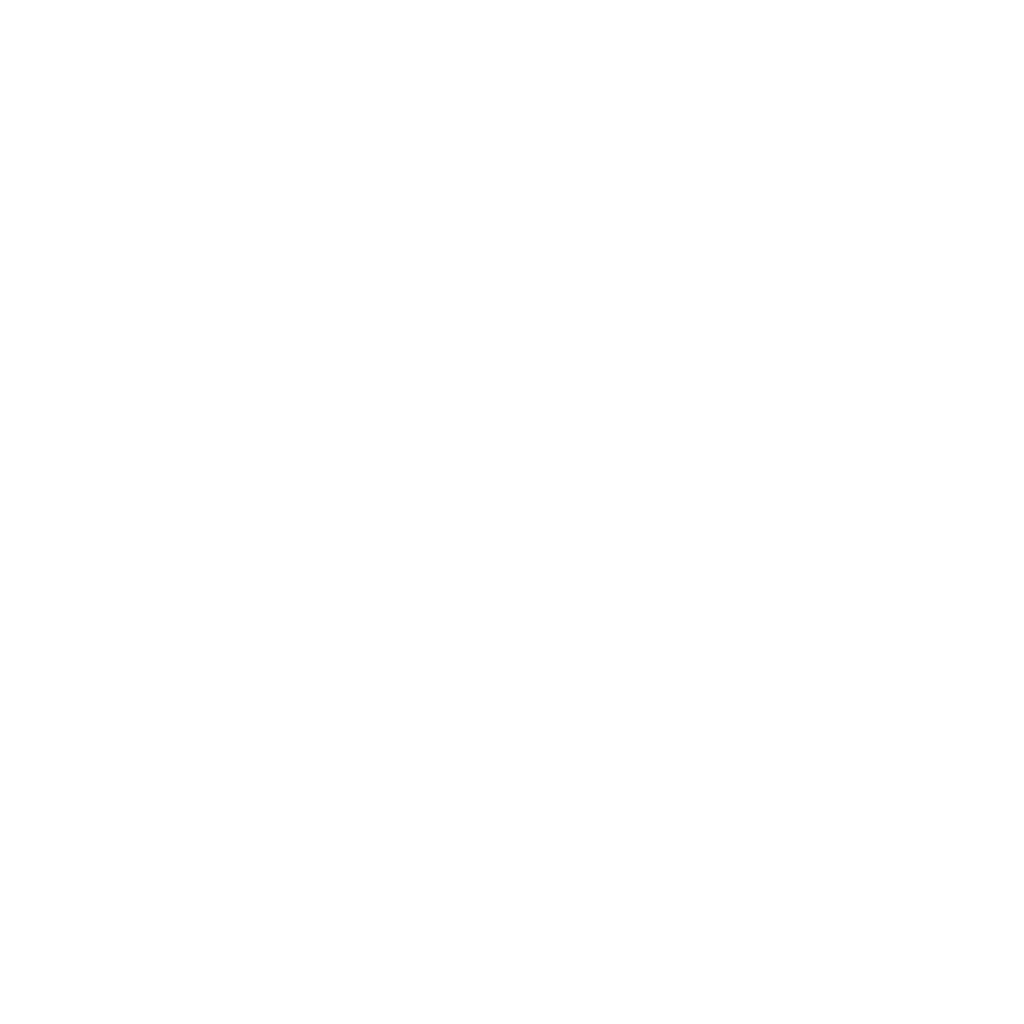

In [45]:
Image.fromarray(im_a_rec)

tensor([0], device='cuda:0')


100%|██████████| 64/64 [00:47<00:00,  1.35it/s]


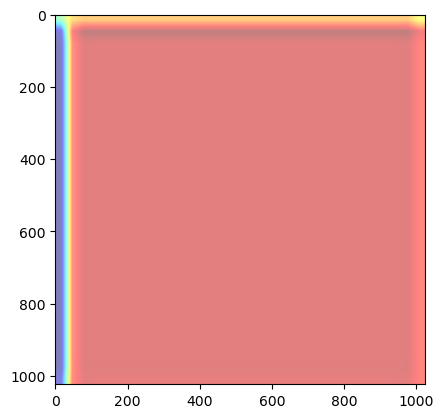

In [46]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/model-1m1bkrw240-output/ablationcam_analysis/ablated_img_PD090_Syn1_CG.svs_x_4279_y_15347_3.png"
gc, pred =ablationCam(model_ft, im)

tensor([1], device='cuda:0')


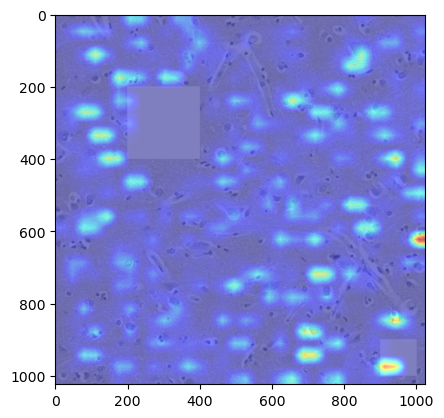

: 

In [52]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_samples_for_testing/Good_GM/model-1m1bkrw240-output/ablationcam_analysis/ablated_img_PD090_Syn1_CG.svs_x_4279_y_15347.png"
gc, pred =gradcam(model_ft, im)